In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from itertools import product
from statsmodels.tsa.arima.model import ARIMA

from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# -------------------------
# Config
# -------------------------
DATA_PATH = "retail_store_inventory.csv"

DATE_COL = "Date"
TARGET_COL = "Units Sold"
ID_COLS = ["Store ID", "Product ID"]

TRAIN_FRACTION = 0.8          # time-based split
MIN_TOTAL_DAYS = 60           # skip series quá ngắn (sau khi reindex daily)
MAX_SERIES = None             # None = chạy tất cả, hoặc set int để debug

# ARIMA grid search (nhỏ để chạy ổn trên nhiều series)
P_RANGE = range(0, 3)   # 0,1,2
D_RANGE = range(0, 2)   # 0,1
Q_RANGE = range(0, 3)   # 0,1,2

# Nếu muốn bỏ grid search để chạy nhanh:
USE_GRID_SEARCH = True
DEFAULT_ORDER = (1, 1, 1)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -------------------------
# Metrics helpers
# -------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return float(2.0 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

def evaluate_forecast(y_true, y_pred):
    return {
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "wape": wape(y_true, y_pred),
    }

# -------------------------
# Load data
# -------------------------
candidate_paths = [
    Path(DATA_PATH),
    Path("../input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv"),
]
data_path = next((p for p in candidate_paths if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Không tìm thấy CSV. Hãy kiểm tra DATA_PATH hoặc đường dẫn Kaggle input.")

print(f"Using data file: {data_path.resolve()}")

df = pd.read_csv(data_path)
print("Raw shape:", df.shape)

# Parse dates & sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(ID_COLS + [DATE_COL]).reset_index(drop=True)

# Clean target
df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=[TARGET_COL], inplace=True)

print("Cleaned shape:", df.shape)
display(df.head())


Using data file: /content/retail_store_inventory.csv
Raw shape: (73100, 15)
Cleaned shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127.0,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-02,S001,P0001,Groceries,West,116,81.0,104,92.94,27.95,10,Cloudy,0,30.89,Spring
2,2022-01-03,S001,P0001,Electronics,West,154,5.0,189,5.36,62.70,20,Rainy,0,58.22,Winter
3,2022-01-04,S001,P0001,Groceries,South,85,58.0,193,52.87,77.88,15,Cloudy,1,75.99,Winter
4,2022-01-05,S001,P0001,Groceries,South,238,147.0,37,150.27,28.46,20,Sunny,1,29.40,Winter


In [2]:

# -------------------------
# Build list of series
# -------------------------
counts = (
    df.groupby(ID_COLS)[TARGET_COL]
      .count()
      .sort_values(ascending=False)
)

print("Total series:", len(counts))
print("Top 10 series by length:")
display(counts.head(10).reset_index().rename(columns={TARGET_COL: "n_obs"}))

series_keys = list(counts.index)

if MAX_SERIES is not None:
    series_keys = series_keys[: int(MAX_SERIES)]
    print(f"\nMAX_SERIES={MAX_SERIES} => chạy {len(series_keys)} series đầu tiên (theo độ dài giảm dần).")

# Optional: xem phân phối độ dài
counts.reset_index(name="n_obs")["n_obs"].describe()


Total series: 100
Top 10 series by length:


,Store ID,Product ID,n_obs
0,S001,P0001,731
1,S001,P0002,731
2,S001,P0003,731
3,S001,P0004,731
4,S001,P0005,731
5,S001,P0006,731
6,S001,P0007,731
7,S001,P0008,731
8,S001,P0009,731
9,S001,P0010,731


,n_obs
count,100.0
mean,731.0
std,0.0
min,731.0
25%,731.0
50%,731.0
75%,731.0
max,731.0


In [3]:

# -------------------------
# Helpers per series
# -------------------------
def build_daily_series(df, store_id, product_id):
    sub = df[(df["Store ID"] == store_id) & (df["Product ID"] == product_id)][[DATE_COL, TARGET_COL]].copy()
    sub = sub.sort_values(DATE_COL).set_index(DATE_COL)
    sub = sub.asfreq("D")
    y = sub[TARGET_COL].fillna(0.0).astype(float)
    return y

def split_train_test(y):
    n = len(y)
    train_size = int(n * TRAIN_FRACTION)
    train = y.iloc[:train_size]
    test = y.iloc[train_size:]
    return train, test

def naive7_for_test(train, test):
    full = pd.concat([train, test], axis=0)
    yhat = full.shift(7)
    yhat_test = yhat.loc[test.index]
    if yhat_test.isna().any():
        fallback = float(train.mean()) if len(train) else 0.0
        yhat_test = yhat_test.fillna(fallback)
    return yhat_test

def fit_best_arima(train):
    if not USE_GRID_SEARCH:
        model = ARIMA(train, order=DEFAULT_ORDER, enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit()
        return res, DEFAULT_ORDER, float(res.aic)

    best_aic = np.inf
    best_order = None
    best_res = None

    for p, d, q in product(P_RANGE, D_RANGE, Q_RANGE):
        try:
            model = ARIMA(train, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
            res = model.fit()
            aic = float(res.aic)
            if np.isfinite(aic) and aic < best_aic:
                best_aic = aic
                best_order = (p, d, q)
                best_res = res
        except Exception:
            continue

    return best_res, best_order, float(best_aic) if np.isfinite(best_aic) else np.nan


In [4]:

# -------------------------
# Run over ALL series
# -------------------------
rows = []
skipped_short = 0
failed_fit = 0

for (store_id, product_id) in series_keys:
    y = build_daily_series(df, store_id, product_id)
    total_days = len(y)

    row = {
        "Store ID": store_id,
        "Product ID": product_id,
        "total_days": int(total_days),
    }

    if total_days < MIN_TOTAL_DAYS:
        skipped_short += 1
        row.update({
            "status": "skipped_short",
            "train_days": np.nan,
            "test_days": np.nan,
        })
        rows.append(row)
        continue

    train, test = split_train_test(y)

    # Need at least 14 test points to compute Naive-7 sensibly
    if len(train) < 14 or len(test) < 14:
        skipped_short += 1
        row.update({
            "status": "skipped_short_split",
            "train_days": int(len(train)),
            "test_days": int(len(test)),
        })
        rows.append(row)
        continue

    row.update({"train_days": int(len(train)), "test_days": int(len(test))})

    # Baseline
    yhat_naive = naive7_for_test(train, test)
    base_metrics = evaluate_forecast(test.values, yhat_naive.values)
    row.update({f"naive7_{k}": v for k, v in base_metrics.items()})

    # ARIMA
    try:
        best_res, best_order, best_aic = fit_best_arima(train)
        if best_res is None:
            raise RuntimeError("No ARIMA model converged.")
        fc = best_res.get_forecast(steps=len(test))
        yhat = fc.predicted_mean
        # Align index to test (for safety)
        yhat = pd.Series(np.asarray(yhat), index=test.index)
        arima_metrics = evaluate_forecast(test.values, yhat.values)

        row.update({
            "status": "ok",
            "arima_order": str(best_order),
            "arima_aic": best_aic,
            **{f"arima_{k}": v for k, v in arima_metrics.items()},
        })
    except Exception as e:
        failed_fit += 1
        row.update({
            "status": f"failed_fit",
            "arima_order": None,
            "arima_aic": np.nan,
            "arima_rmse": np.nan,
            "arima_mape": np.nan,
            "arima_smape": np.nan,
            "arima_wape": np.nan,
            "error": str(e)[:300],
        })

    rows.append(row)

results_df = pd.DataFrame(rows)

print("Done.")
print("Series OK:", int((results_df["status"] == "ok").sum()))
print("Skipped (short):", skipped_short)
print("Failed fit:", failed_fit)

display(results_df.head())


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Done.
Series OK: 100
Skipped (short): 0
Failed fit: 0


,Store ID,Product ID,total_days,train_days,test_days,naive7_rmse,naive7_mape,naive7_smape,naive7_wape,status,arima_order,arima_aic,arima_rmse,arima_mape,arima_smape,arima_wape
0,S001,P0001,731,584,147,153.244325,263.187383,87.460311,86.018721,ok,"(0, 1, 2)",7089.563658,109.580232,211.852961,72.826219,66.394790
1,S001,P0002,731,584,147,136.183100,371.800761,93.561515,91.053333,ok,"(0, 1, 2)",7056.907818,96.793175,305.869860,72.277613,67.125434
2,S001,P0003,731,584,147,166.175856,490.005445,98.399243,95.269301,ok,"(0, 1, 2)",7059.992564,110.532589,394.678553,73.562029,66.238630
3,S001,P0004,731,584,147,159.375610,245.619037,92.154617,85.769466,ok,"(0, 1, 2)",7149.828005,113.205746,297.781409,72.705966,65.560584
4,S001,P0005,731,584,147,151.135521,328.706451,91.767838,85.973317,ok,"(2, 1, 2)",7078.721290,106.947456,314.154789,71.985489,65.618073


In [6]:
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def arima_grid_search(
    train_series,
    p_values=range(0, 5),
    d_values=(0, 1),
    q_values=range(0, 5),
    seasonal_order=(0, 0, 0, 0),
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
    maxiter=200,
):
    y = train_series

    # Accept Series / DataFrame
    if isinstance(y, pd.DataFrame):
        if "y" in y.columns:
            y = y["y"]
        else:
            y = y.iloc[:, 0]

    y = pd.Series(y).astype(float)
    y = y.replace([np.inf, -np.inf], np.nan).dropna()
    y = y.sort_index()

    # Too short -> skip
    if len(y) < 10:
        return None, None, np.inf

    best_aic = np.inf
    best_res = None
    best_order = None

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        model = SARIMAX(
                            y,
                            order=(p, d, q),
                            seasonal_order=seasonal_order,
                            trend=trend,
                            enforce_stationarity=enforce_stationarity,
                            enforce_invertibility=enforce_invertibility,
                        )
                        res = model.fit(disp=False, maxiter=maxiter)

                    aic = res.aic
                    if np.isfinite(aic) and aic < best_aic:
                        best_aic = aic
                        best_res = res
                        best_order = (p, d, q)

                except Exception:
                    continue

    return best_res, best_order, best_aic


Average metrics (mean over all OK series):


,metric,mean_over_series
0,naive7_rmse,151.913444
1,naive7_mape,359.509940
2,naive7_smape,92.989090
3,naive7_wape,87.447331
4,arima_rmse,108.238601
5,arima_mape,343.758321
6,arima_smape,72.211168
7,arima_wape,65.718936


Saved: /content/outputs_arima_allseries/arima_per_series_metrics.csv
Saved: /content/outputs_arima_allseries/arima_mean_metrics.csv


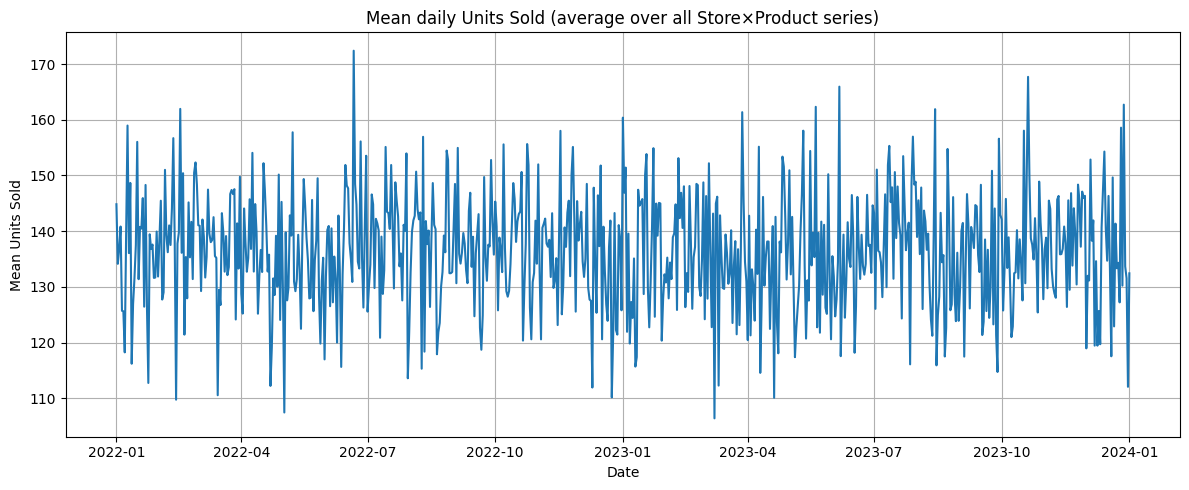

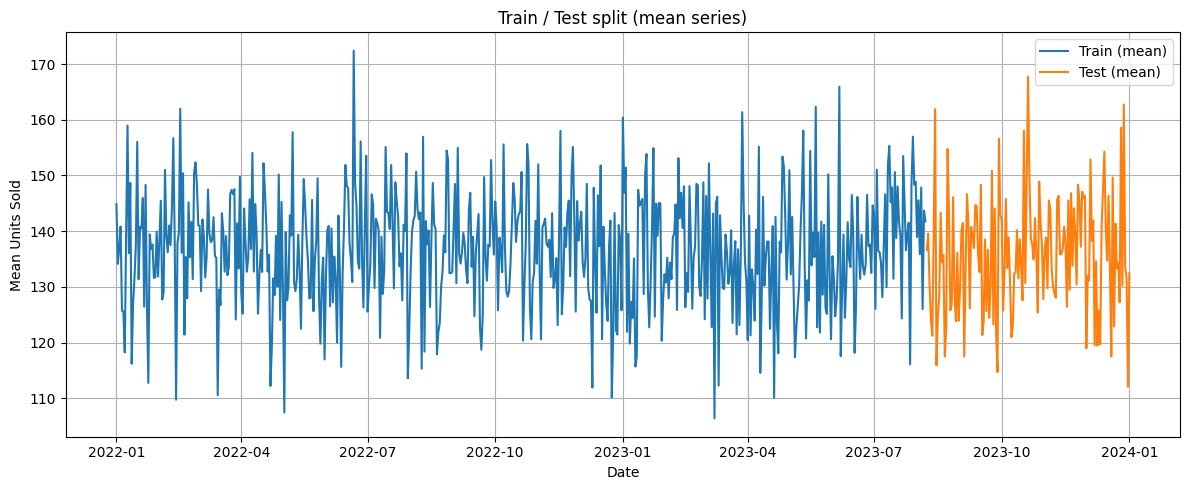

ADF p-value (train mean): 0.0


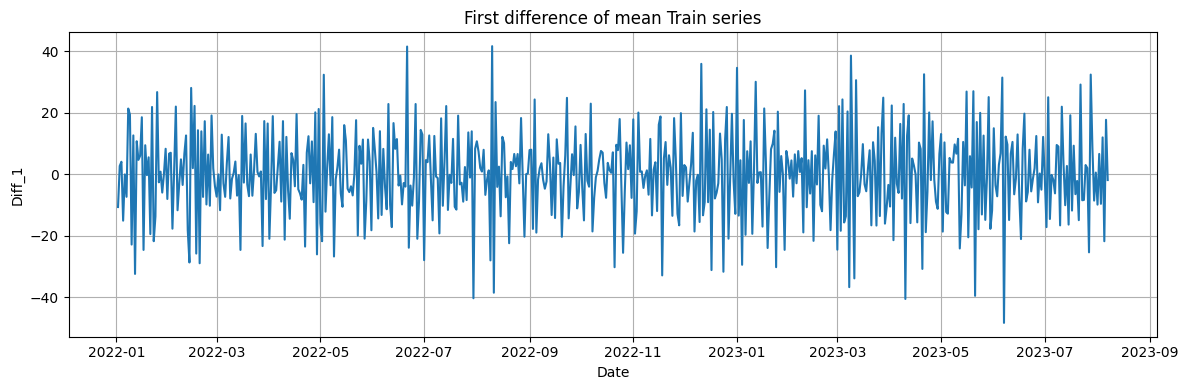

ADF p-value (1st diff train mean): 7.777085838915806e-18


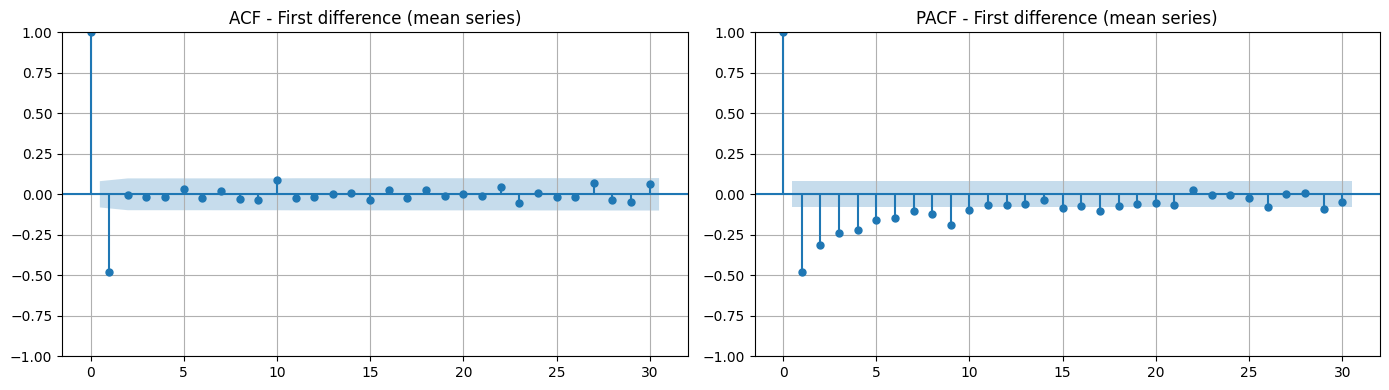

Naive-7 baseline metrics on mean series (Test): {'rmse': 14.983506419588519, 'mape': 8.507222151591298, 'smape': 8.447639708339064, 'wape': 8.462410672940942}


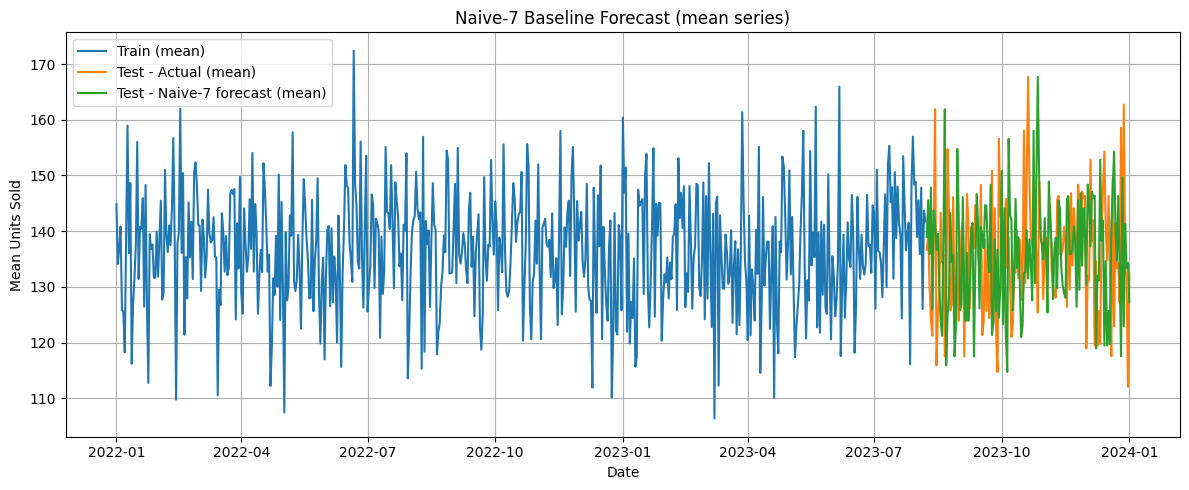

Best ARIMA on mean series: order=(3, 1, 4), AIC=4339.807
ARIMA metrics on mean series (Test): {'rmse': 10.440705777267997, 'mape': 6.225337429678525, 'smape': 6.159689994816289, 'wape': 6.159803162615569}


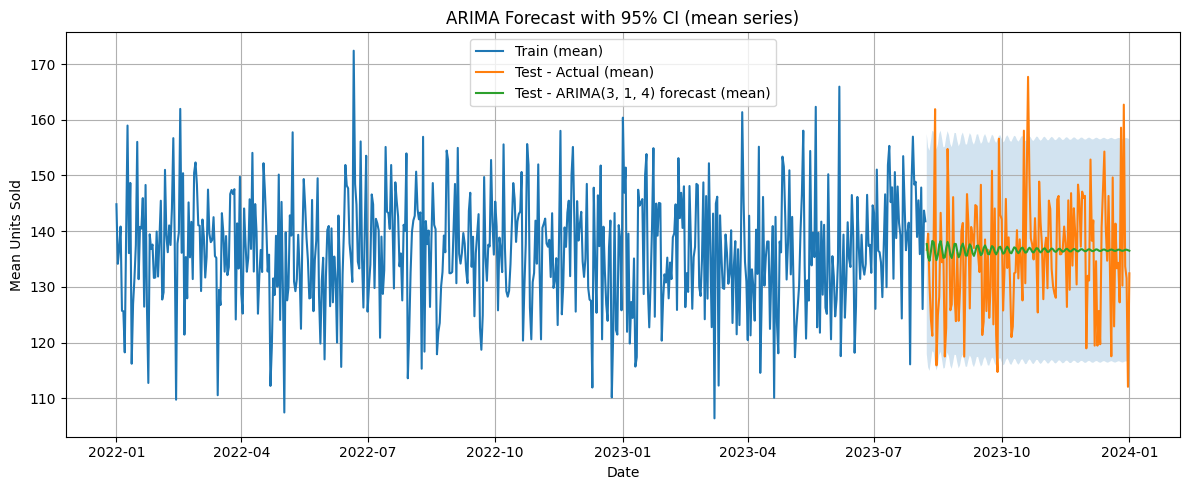

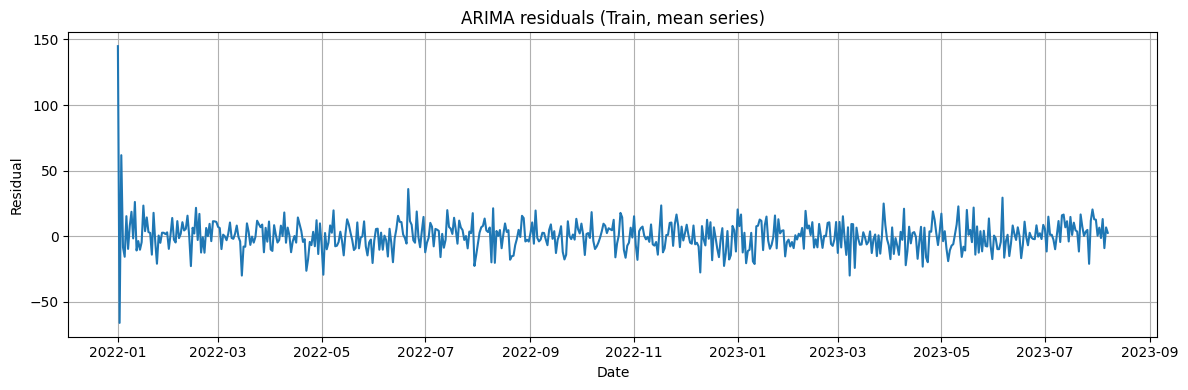

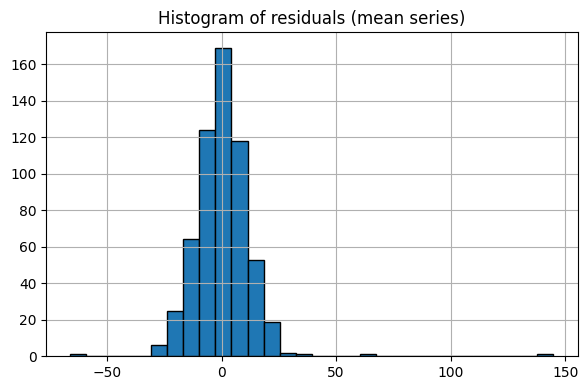

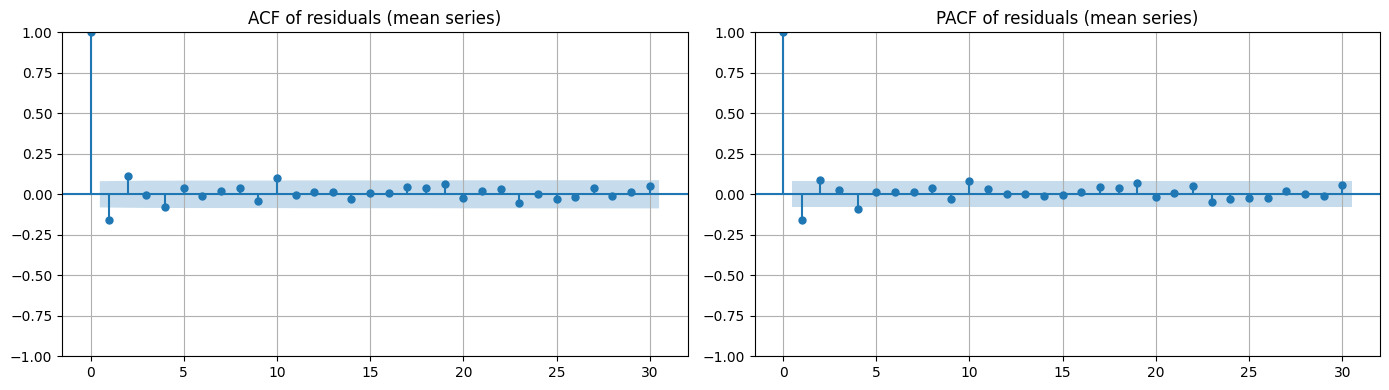

Ljung–Box test on residuals (mean series):


,lb_stat,lb_pvalue
10,35.474681,0.000104
20,40.824630,0.003923


In [7]:

# -------------------------
# Average metrics across all series
# -------------------------
metric_cols = [
    "naive7_rmse","naive7_mape","naive7_smape","naive7_wape",
    "arima_rmse","arima_mape","arima_smape","arima_wape",
]

summary = results_df.loc[results_df["status"] == "ok", metric_cols].mean(numeric_only=True)
summary_df = summary.to_frame(name="mean_over_series").reset_index().rename(columns={"index": "metric"})

print("Average metrics (mean over all OK series):")
display(summary_df)

# Export
output_dir = Path("outputs_arima_allseries")
output_dir.mkdir(parents=True, exist_ok=True)

results_path = output_dir / "arima_per_series_metrics.csv"
summary_path = output_dir / "arima_mean_metrics.csv"

results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print("Saved:", results_path.resolve())
print("Saved:", summary_path.resolve())

# -------------------------
# Plots trên chuỗi TRUNG BÌNH (mean của tất cả series)
# -------------------------
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

mean_df = (
    df.groupby(DATE_COL)[TARGET_COL]
      .mean()
      .sort_index()
      .to_frame("y_mean")
      .asfreq("D")
)
mean_df["y_mean"] = mean_df["y_mean"].fillna(0.0)

y_mean = mean_df["y_mean"].astype(float)

plt.figure(figsize=(12,5))
plt.plot(y_mean.index, y_mean.values)
plt.title(f"Mean daily {TARGET_COL} (average over all Store×Product series)")
plt.xlabel("Date")
plt.ylabel(f"Mean {TARGET_COL}")
plt.tight_layout()
plt.show()

train_m, test_m = split_train_test(y_mean)

plt.figure(figsize=(12,5))
plt.plot(train_m.index, train_m.values, label="Train (mean)")
plt.plot(test_m.index, test_m.values, label="Test (mean)")
plt.title("Train / Test split (mean series)")
plt.xlabel("Date")
plt.ylabel(f"Mean {TARGET_COL}")
plt.legend()
plt.tight_layout()
plt.show()

def adf_pvalue(series):
    try:
        return float(adfuller(series.dropna(), autolag="AIC")[1])
    except Exception:
        return np.nan

print("ADF p-value (train mean):", adf_pvalue(train_m))

train_diff1 = train_m.diff().dropna()

plt.figure(figsize=(12,4))
plt.plot(train_diff1.index, train_diff1.values)
plt.title("First difference of mean Train series")
plt.xlabel("Date")
plt.ylabel("Diff_1")
plt.tight_layout()
plt.show()

print("ADF p-value (1st diff train mean):", adf_pvalue(train_diff1))

lags = int(min(30, max(5, len(train_diff1) - 1)))
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train_diff1, ax=axes[0], lags=lags)
plot_pacf(train_diff1, ax=axes[1], lags=lags, method="ywm")
axes[0].set_title("ACF - First difference (mean series)")
axes[1].set_title("PACF - First difference (mean series)")
plt.tight_layout()
plt.show()

# Naive-7 baseline trên mean series
naive_m = naive7_for_test(train_m, test_m)
base_m = evaluate_forecast(test_m.values, naive_m.values)
print("Naive-7 baseline metrics on mean series (Test):", base_m)

plt.figure(figsize=(12,5))
plt.plot(train_m.index, train_m.values, label="Train (mean)")
plt.plot(test_m.index, test_m.values, label="Test - Actual (mean)")
plt.plot(test_m.index, naive_m.values, label="Test - Naive-7 forecast (mean)")
plt.title("Naive-7 Baseline Forecast (mean series)")
plt.xlabel("Date")
plt.ylabel(f"Mean {TARGET_COL}")
plt.legend()
plt.tight_layout()
plt.show()

# ARIMA fit + forecast trên mean series
best_res_m, best_order_m, best_aic_m = arima_grid_search(train_m)
if best_res_m is None:
    print("Không fit được ARIMA cho mean series với grid hiện tại.")
else:
    fc = best_res_m.get_forecast(steps=len(test_m))
    yhat = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)

    yhat.index = test_m.index
    ci.index = test_m.index

    arima_m = evaluate_forecast(test_m.values, yhat.values)
    print(f"Best ARIMA on mean series: order={best_order_m}, AIC={best_aic_m:.3f}")
    print("ARIMA metrics on mean series (Test):", arima_m)

    plt.figure(figsize=(12,5))
    plt.plot(train_m.index, train_m.values, label="Train (mean)")
    plt.plot(test_m.index, test_m.values, label="Test - Actual (mean)")
    plt.plot(test_m.index, yhat.values, label=f"Test - ARIMA{best_order_m} forecast (mean)")
    try:
        plt.fill_between(test_m.index, ci.iloc[:,0].values, ci.iloc[:,1].values, alpha=0.2)
    except Exception:
        pass
    plt.title("ARIMA Forecast with 95% CI (mean series)")
    plt.xlabel("Date")
    plt.ylabel(f"Mean {TARGET_COL}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Residual diagnostics (train, mean series)
    resid = best_res_m.resid.dropna()

    plt.figure(figsize=(12,4))
    plt.plot(resid.index, resid.values)
    plt.title("ARIMA residuals (Train, mean series)")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(resid.values, bins=30, edgecolor="black")
    plt.title("Histogram of residuals (mean series)")
    plt.tight_layout()
    plt.show()

    lags_r = int(min(30, max(5, len(resid) - 1)))
    fig, axes = plt.subplots(1,2, figsize=(14,4))
    plot_acf(resid, ax=axes[0], lags=lags_r)
    plot_pacf(resid, ax=axes[1], lags=lags_r, method="ywm")
    axes[0].set_title("ACF of residuals (mean series)")
    axes[1].set_title("PACF of residuals (mean series)")
    plt.tight_layout()
    plt.show()

    try:
        lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
        print("Ljung–Box test on residuals (mean series):")
        display(lb)
    except Exception as e:
        print("Ljung–Box test failed:", str(e)[:200])
